# Análise Exploratória - Censo Escolar 2025

Análise exploratória - Censo Escolar 2025
Univariada e multivariada, com Pandas, Matplotlib e Seaborn.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Paleta de cores customizada: preto -> tons de azul -> cinza claro
PALETA = ['#0D1B2A', '#1B3A5C', '#2E5C8A', '#4C7FA8', '#7FA8C9', '#B0C4D4', '#D9D9D9']
COR_PADRAO = PALETA[3]  # cor usada nos gráficos de uma categoria só (não o azul padrão do seaborn)
sns.set_style("whitegrid")

# Nomes legíveis para as colunas de infraestrutura (usados nos rótulos dos gráficos)
NOMES_RECURSOS = {
    "in_internet": "Internet",
    "in_biblioteca": "Biblioteca",
    "in_laboratorio_informatica": "Lab. informática",
    "in_laboratorio_ciencias": "Lab. ciências",
    "in_quadra_esportes": "Quadra de esportes",
}

# Pasta de saída para as imagens
os.makedirs("graficos", exist_ok=True)

# Carregar dataset já limpo
df = pd.read_csv("data/dataset_escolas_censo2025_limpo.csv")

# Mapear códigos para rótulos legíveis (facilita a leitura dos gráficos)
df["dependencia"] = df["tp_dependencia"].map({
    1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada"
})
df["localizacao"] = df["tp_localizacao"].map({1: "Urbana", 2: "Rural"})
df["situacao"] = df["tp_situacao_funcionamento"].map({
    1: "Em atividade", 2: "Paralisada", 3: "Extinta"
})
df["rede"] = df["tp_dependencia"].map({
    1: "Pública", 2: "Pública", 3: "Pública", 4: "Privada"
})

# Para as análises seguintes, olhar só para escolas em atividade
# (paralisadas/extintas têm dados de infraestrutura zerados por não operarem)
df_ativas = df[df["situacao"] == "Em atividade"].copy()


def rotular_barras(ax, formato="{:,.0f}"):
    """Escreve o valor de cada barra em cima dela, com separador de milhar."""
    for p in ax.patches:
        altura = p.get_height()
        if pd.isna(altura) or altura == 0:
            continue
        ax.annotate(formato.format(altura),
                    (p.get_x() + p.get_width() / 2, altura),
                    ha="center", va="bottom", fontsize=9)


def formatar_eixo_milhar(ax, eixo="y"):
    """Formata os números de um eixo com separador de milhar (ex: 10,000)."""
    formatter = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    if eixo == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)


def ajustar_rotulos_x(ax, rotacao=20):
    """Rotaciona os rótulos do eixo x e alinha à direita, para não cortar o texto."""
    plt.setp(ax.get_xticklabels(), rotation=rotacao, ha="right")


# ANÁLISE UNIVARIADA

## Escolas por região

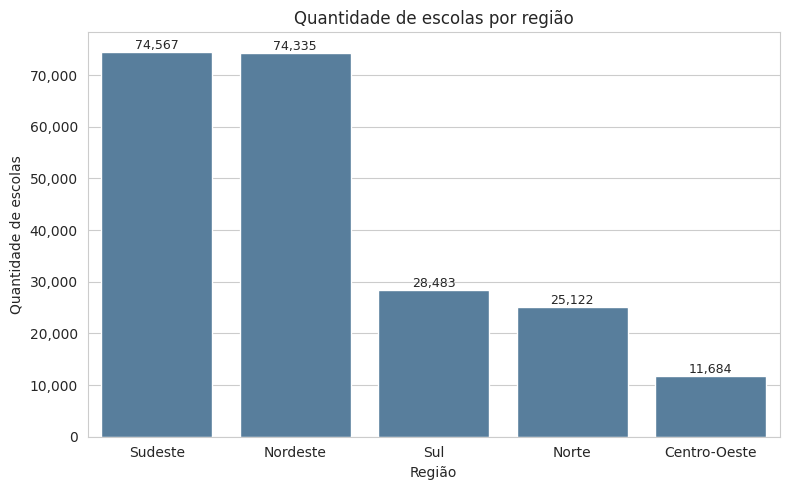

In [2]:
contagem_regiao = df["no_regiao"].value_counts()
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=contagem_regiao.index, y=contagem_regiao.values, color=COR_PADRAO)
plt.title("Quantidade de escolas por região")
plt.xlabel("Região")
plt.ylabel("Quantidade de escolas")
formatar_eixo_milhar(ax)
rotular_barras(ax)
plt.tight_layout()
plt.savefig("graficos/01_escolas_por_regiao.png")
plt.show()
plt.close()

## Escolas por dependência administrativa

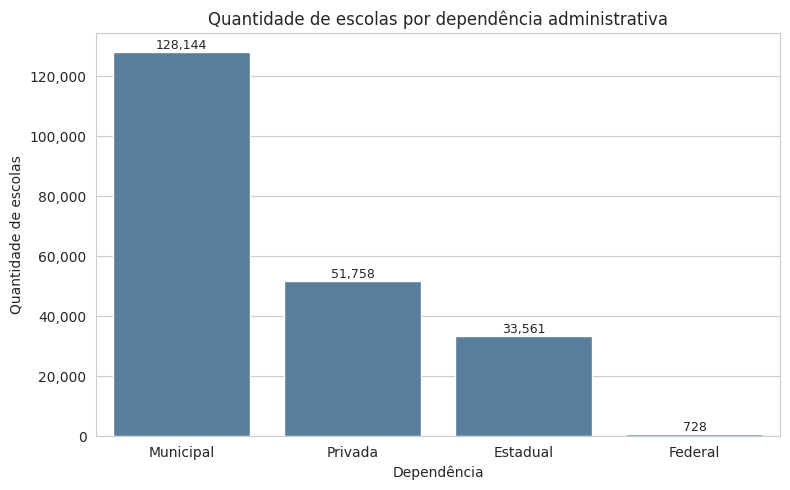

In [3]:
contagem_dependencia = df["dependencia"].value_counts()
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=contagem_dependencia.index, y=contagem_dependencia.values, color=COR_PADRAO)
plt.title("Quantidade de escolas por dependência administrativa")
plt.xlabel("Dependência")
plt.ylabel("Quantidade de escolas")
formatar_eixo_milhar(ax)
rotular_barras(ax)
plt.tight_layout()
plt.savefig("graficos/02_escolas_por_dependencia.png")
plt.show()
plt.close()

## Escolas por localização (urbana/rural)

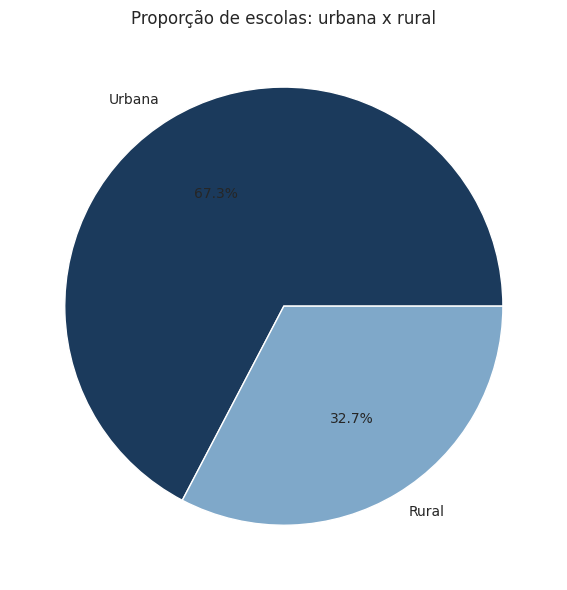

In [4]:
contagem_localizacao = df["localizacao"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(contagem_localizacao.values, labels=contagem_localizacao.index,
        colors=[PALETA[1], PALETA[4]], autopct="%1.1f%%")
plt.title("Proporção de escolas: urbana x rural")
plt.tight_layout()
plt.savefig("graficos/03_escolas_urbana_rural.png")
plt.show()
plt.close()

## Situação de funcionamento

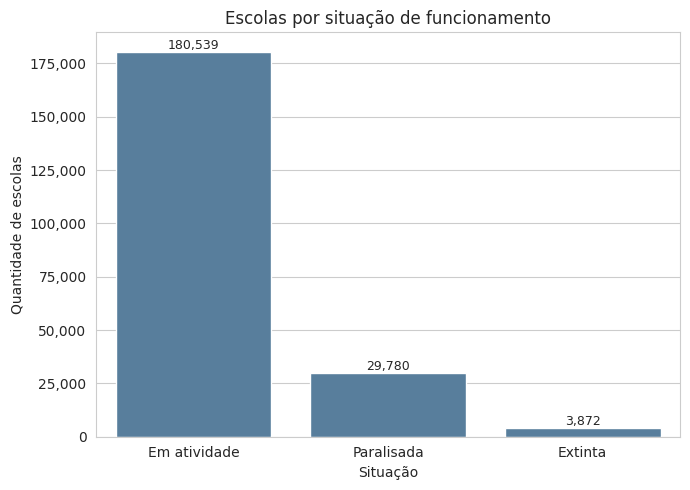

In [5]:
contagem_situacao = df["situacao"].value_counts()
plt.figure(figsize=(7, 5))
ax = sns.barplot(x=contagem_situacao.index, y=contagem_situacao.values, color=COR_PADRAO)
plt.title("Escolas por situação de funcionamento")
plt.xlabel("Situação")
plt.ylabel("Quantidade de escolas")
formatar_eixo_milhar(ax)
rotular_barras(ax)
plt.tight_layout()
plt.savefig("graficos/04_situacao_funcionamento.png")
plt.show()
plt.close()

## Distribuição do total de matrículas por escola

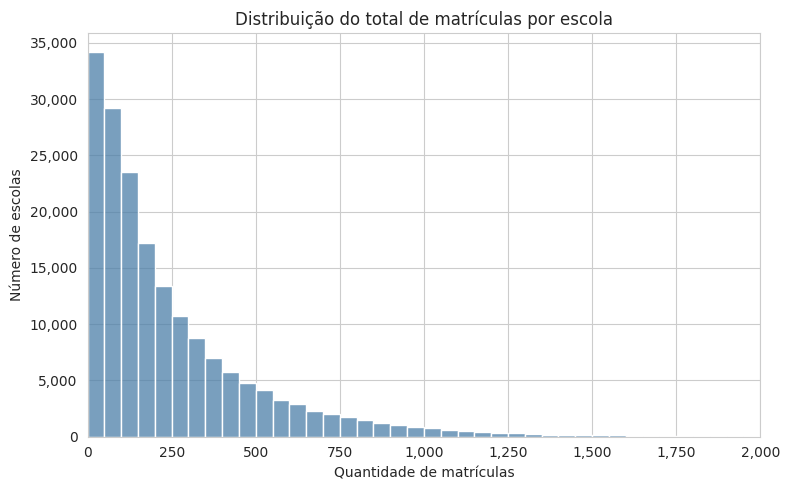

In [6]:
plt.figure(figsize=(8, 5))
dados_hist = df_ativas[df_ativas["qt_mat_bas"] <= 2000]["qt_mat_bas"]
ax = sns.histplot(dados_hist, bins=40, binrange=(0, 2000), color=COR_PADRAO)
plt.title("Distribuição do total de matrículas por escola")
plt.xlabel("Quantidade de matrículas")
plt.ylabel("Número de escolas")
plt.xlim(0, 2000)  # recorte para melhor leitura, já que há outliers de escolas muito grandes
formatar_eixo_milhar(ax, eixo="x")
formatar_eixo_milhar(ax, eixo="y")
plt.tight_layout()
plt.savefig("graficos/05_distribuicao_matriculas.png")
plt.show()
plt.close()

## Proporção de escolas com acesso à internet

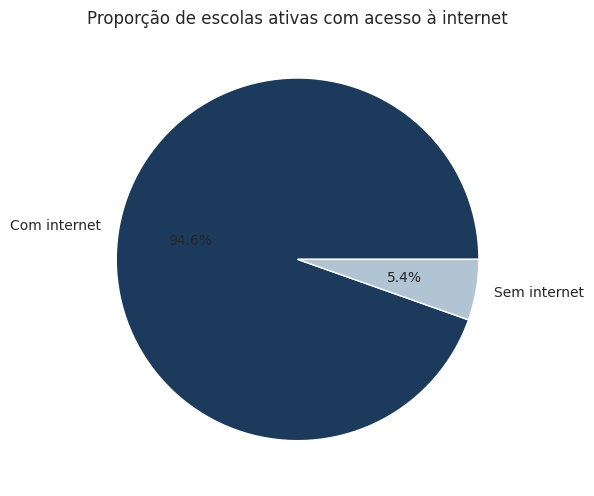

In [7]:
contagem_internet = df_ativas["in_internet"].map({1: "Com internet", 0: "Sem internet"}).value_counts()
plt.figure(figsize=(6, 6))
plt.pie(contagem_internet.values, labels=contagem_internet.index,
        colors=[PALETA[1], PALETA[5]], autopct="%1.1f%%")
plt.title("Proporção de escolas ativas com acesso à internet")
plt.tight_layout()
plt.savefig("graficos/06_escolas_com_internet.png")
plt.show()
plt.close()

## Distribuição de escolas por porte (pequena/média/grande, pelo total de matrículas)

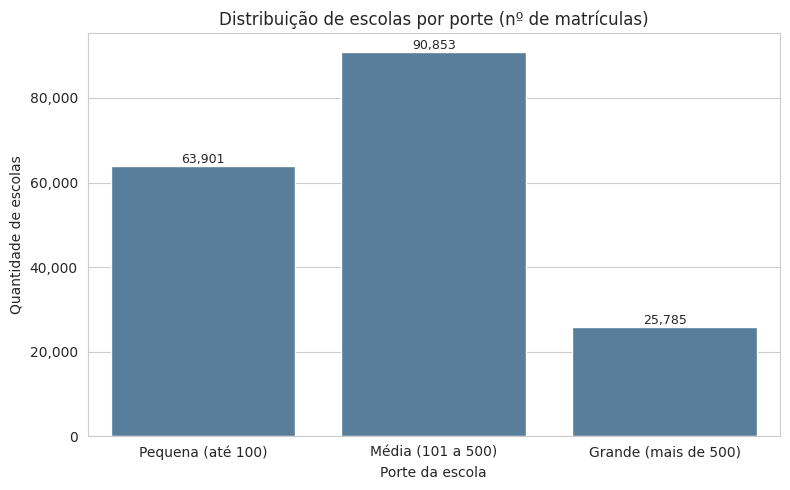

In [8]:
bins_porte = [-1, 100, 500, float("inf")]
labels_porte = ["Pequena (até 100)", "Média (101 a 500)", "Grande (mais de 500)"]
df_ativas["porte"] = pd.cut(df_ativas["qt_mat_bas"], bins=bins_porte, labels=labels_porte)
contagem_porte = df_ativas["porte"].value_counts().reindex(labels_porte)
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=contagem_porte.index, y=contagem_porte.values, color=COR_PADRAO)
plt.title("Distribuição de escolas por porte (nº de matrículas)")
plt.xlabel("Porte da escola")
plt.ylabel("Quantidade de escolas")
formatar_eixo_milhar(ax)
rotular_barras(ax)
plt.tight_layout()
plt.savefig("graficos/07_escolas_por_porte.png")
plt.show()
plt.close()


# ANÁLISE MULTIVARIADA

## Matrículas por região e por dependência administrativa

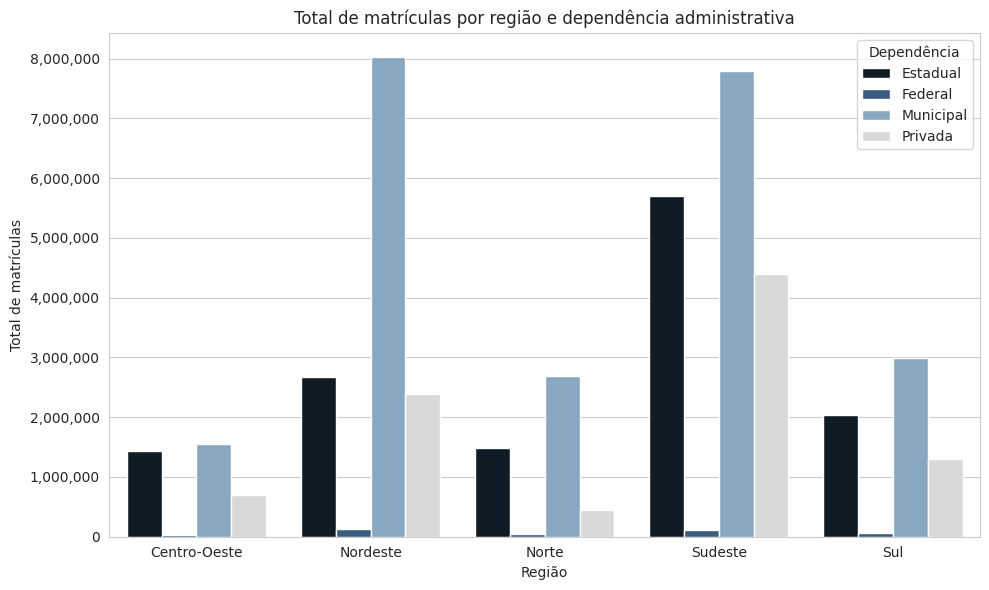

In [9]:
mat_regiao_dependencia = df_ativas.groupby(["no_regiao", "dependencia"])["qt_mat_bas"].sum().reset_index()
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=mat_regiao_dependencia, x="no_regiao", y="qt_mat_bas",
                  hue="dependencia", palette=[PALETA[0], PALETA[2], PALETA[4], PALETA[6]])
plt.title("Total de matrículas por região e dependência administrativa")
plt.xlabel("Região")
plt.ylabel("Total de matrículas")
plt.legend(title="Dependência")
formatar_eixo_milhar(ax)
plt.tight_layout()
plt.savefig("graficos/08_matriculas_regiao_dependencia.png")
plt.show()
plt.close()

## Infraestrutura (internet, biblioteca, laboratório, quadra) por localização

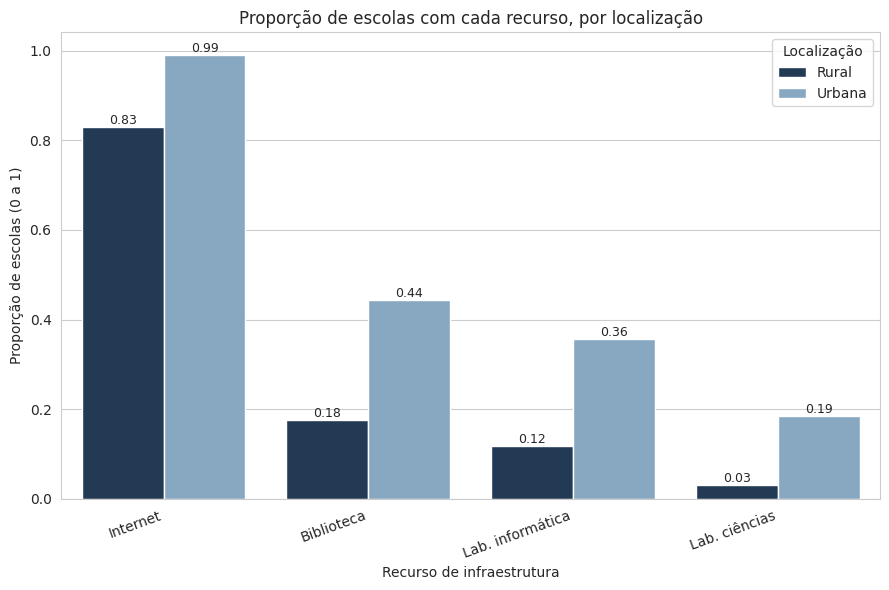

In [10]:
infra_localizacao = df_ativas.groupby("localizacao")[list(NOMES_RECURSOS.keys())[:4]].mean().reset_index()
infra_localizacao_long = infra_localizacao.melt(
    id_vars="localizacao", var_name="recurso", value_name="proporcao"
)
infra_localizacao_long["recurso"] = infra_localizacao_long["recurso"].map(NOMES_RECURSOS)
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=infra_localizacao_long, x="recurso", y="proporcao",
                  hue="localizacao", palette=[PALETA[1], PALETA[4]])
plt.title("Proporção de escolas com cada recurso, por localização")
plt.xlabel("Recurso de infraestrutura")
plt.ylabel("Proporção de escolas (0 a 1)")
ajustar_rotulos_x(ax)
plt.legend(title="Localização")
rotular_barras(ax, formato="{:.2f}")
plt.tight_layout()
plt.savefig("graficos/09_infraestrutura_por_localizacao.png")
plt.show()
plt.close()

## Infraestrutura: pública x privada

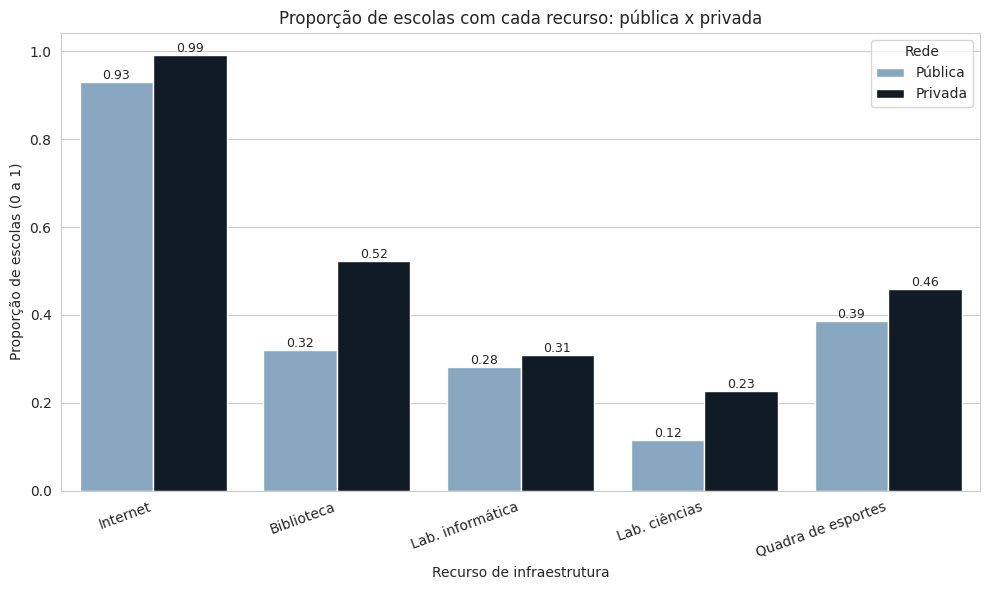

In [11]:
infra_rede = df_ativas.groupby("rede")[list(NOMES_RECURSOS.keys())].mean().reset_index()
infra_rede_long = infra_rede.melt(id_vars="rede", var_name="recurso", value_name="proporcao")
infra_rede_long["recurso"] = infra_rede_long["recurso"].map(NOMES_RECURSOS)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=infra_rede_long, x="recurso", y="proporcao",
                  hue="rede", hue_order=["Pública", "Privada"],
                  palette=[PALETA[4], PALETA[0]])
plt.title("Proporção de escolas com cada recurso: pública x privada")
plt.xlabel("Recurso de infraestrutura")
plt.ylabel("Proporção de escolas (0 a 1)")
ajustar_rotulos_x(ax)
plt.legend(title="Rede")
rotular_barras(ax, formato="{:.2f}")
plt.tight_layout()
plt.savefig("graficos/10_infraestrutura_publica_privada.png")
plt.show()
plt.close()

## Acessibilidade (rampas/corrimão) por região

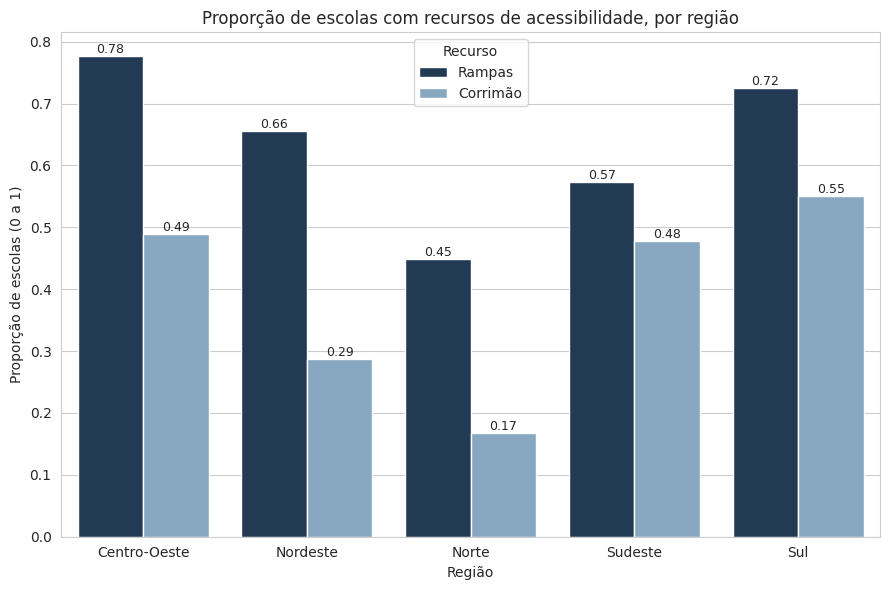

In [12]:
acess_regiao = df_ativas.groupby("no_regiao")[
    ["in_acessibilidade_rampas", "in_acessibilidade_corrimao"]
].mean().reset_index()
acess_regiao_long = acess_regiao.melt(id_vars="no_regiao", var_name="recurso", value_name="proporcao")
acess_regiao_long["recurso"] = acess_regiao_long["recurso"].map({
    "in_acessibilidade_rampas": "Rampas", "in_acessibilidade_corrimao": "Corrimão"
})
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=acess_regiao_long, x="no_regiao", y="proporcao",
                  hue="recurso", palette=[PALETA[1], PALETA[4]])
plt.title("Proporção de escolas com recursos de acessibilidade, por região")
plt.xlabel("Região")
plt.ylabel("Proporção de escolas (0 a 1)")
plt.legend(title="Recurso")
rotular_barras(ax, formato="{:.2f}")
plt.tight_layout()
plt.savefig("graficos/11_acessibilidade_por_regiao.png")
plt.show()
plt.close()

## Matrículas por etapa de ensino

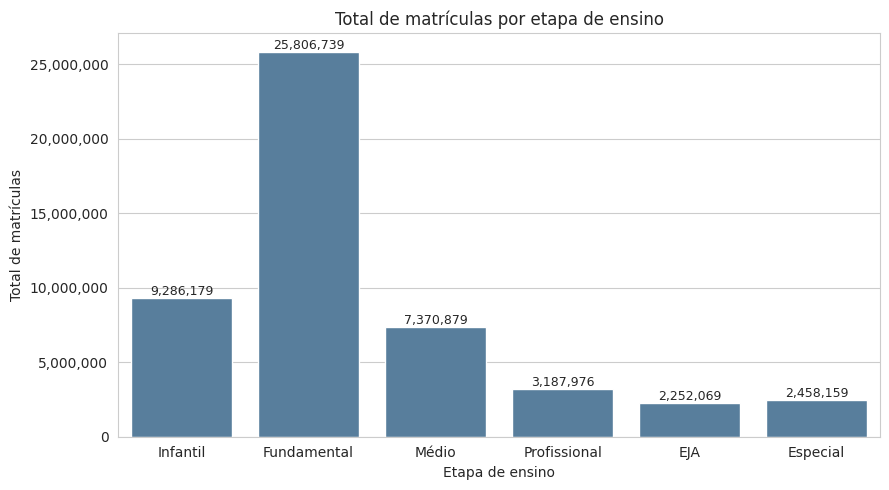

In [13]:
etapas = {
    "qt_mat_inf": "Infantil",
    "qt_mat_fund": "Fundamental",
    "qt_mat_med": "Médio",
    "qt_mat_prof": "Profissional",
    "qt_mat_eja": "EJA",
    "qt_mat_esp": "Especial",
}
total_por_etapa = df_ativas[list(etapas.keys())].sum().rename(index=etapas)
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=total_por_etapa.index, y=total_por_etapa.values, color=COR_PADRAO)
plt.title("Total de matrículas por etapa de ensino")
plt.xlabel("Etapa de ensino")
plt.ylabel("Total de matrículas")
formatar_eixo_milhar(ax)
rotular_barras(ax)
plt.tight_layout()
plt.savefig("graficos/12_matriculas_por_etapa.png")
plt.show()
plt.close()

## Ranking de estados por proporção de escolas com laboratório de informática

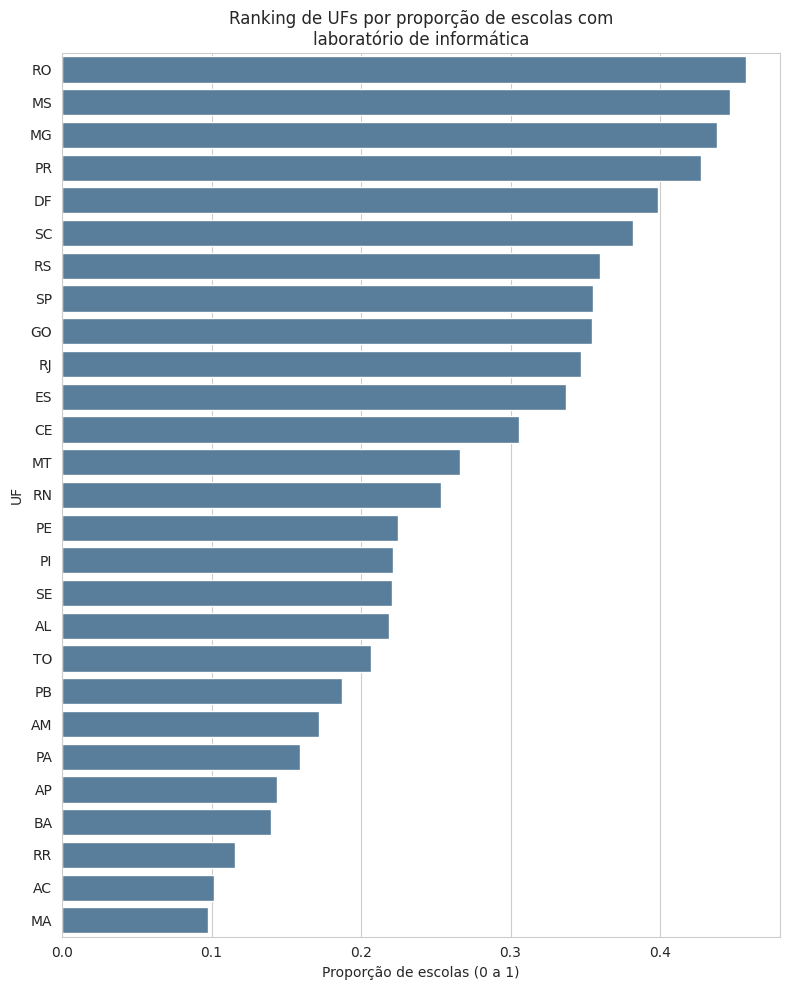

In [14]:
ranking_uf = df_ativas.groupby("sg_uf")["in_laboratorio_informatica"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 10))
ax = sns.barplot(x=ranking_uf.values, y=ranking_uf.index, color=COR_PADRAO)
plt.title("Ranking de UFs por proporção de escolas com\nlaboratório de informática")
plt.xlabel("Proporção de escolas (0 a 1)")
plt.ylabel("UF")
plt.tight_layout()
plt.savefig("graficos/13_ranking_uf_laboratorio_informatica.png")
plt.show()
plt.close()

## Relação entre número de profissionais e total de matrículas

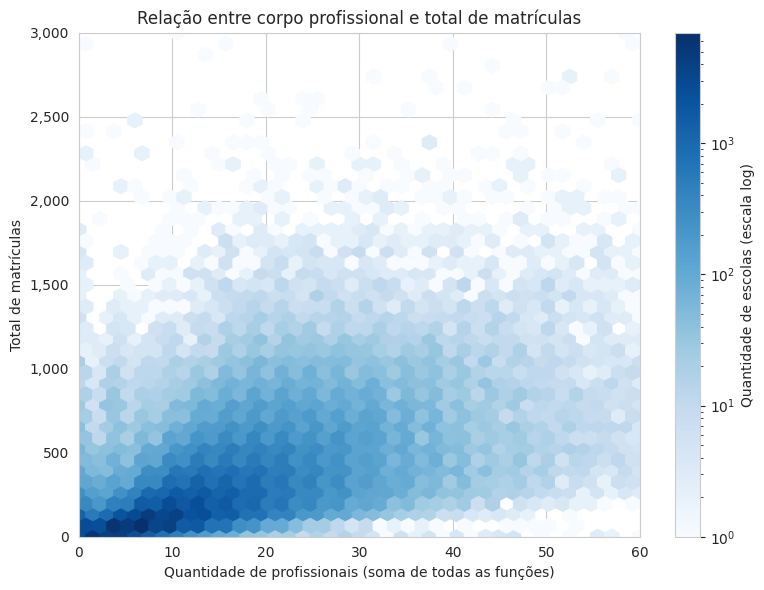

In [15]:
plt.figure(figsize=(8, 6))
soma_profissionais = df_ativas[[c for c in df_ativas.columns if c.startswith("qt_prof_")]].sum(axis=1)
hb = plt.hexbin(soma_profissionais, df_ativas["qt_mat_bas"],
                 gridsize=40, cmap="Blues", mincnt=1, bins="log",
                 extent=(0, 60, 0, 3000))
plt.colorbar(hb, label="Quantidade de escolas (escala log)")
plt.title("Relação entre corpo profissional e total de matrículas")
plt.xlabel("Quantidade de profissionais (soma de todas as funções)")
plt.ylabel("Total de matrículas")
plt.xlim(0, 60)
plt.ylim(0, 3000)
ax = plt.gca()
formatar_eixo_milhar(ax)
plt.tight_layout()
plt.savefig("graficos/14_profissionais_vs_matriculas.png")
plt.show()
plt.close()

## Matriz de correlação entre indicadores de infraestrutura

In [16]:
colunas_infra = [
    "in_agua_potavel", "in_energia_rede_publica", "in_esgoto_rede_publica",
    "in_biblioteca", "in_laboratorio_informatica", "in_laboratorio_ciencias",
    "in_quadra_esportes", "in_internet", "in_internet_alunos",
]
nomes_infra = {
    "in_agua_potavel": "Água potável",
    "in_energia_rede_publica": "Energia elétrica",
    "in_esgoto_rede_publica": "Esgoto",
    "in_biblioteca": "Biblioteca",
    "in_laboratorio_informatica": "Lab. informática",
    "in_laboratorio_ciencias": "Lab. ciências",
    "in_quadra_esportes": "Quadra de esportes",
    "in_internet": "Internet",
    "in_internet_alunos": "Internet p/ alunos",
}

## Matriz de correlação entre indicadores de infraestrutura

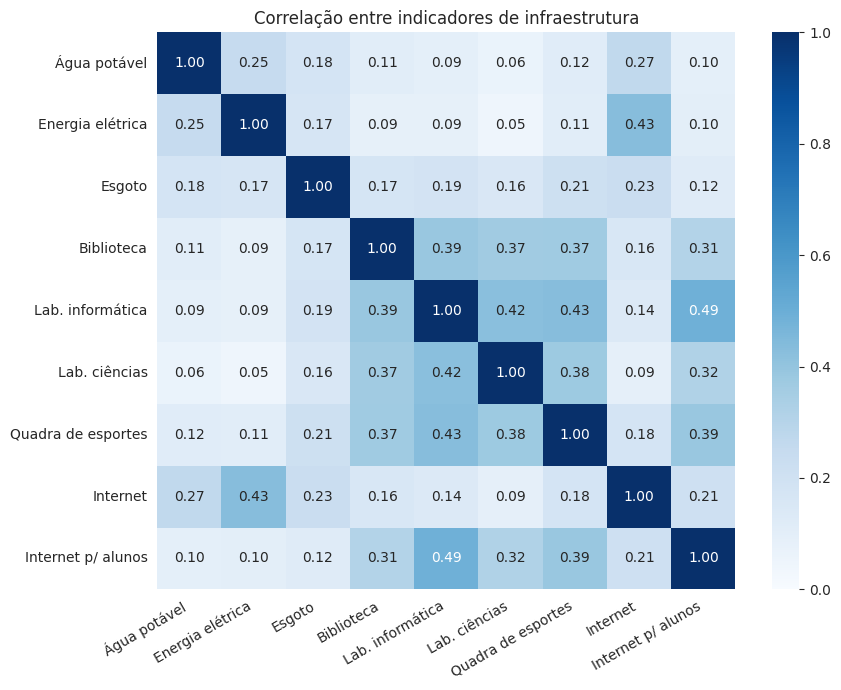

In [17]:
colunas_infra = [
    "in_agua_potavel", "in_energia_rede_publica", "in_esgoto_rede_publica",
    "in_biblioteca", "in_laboratorio_informatica", "in_laboratorio_ciencias",
    "in_quadra_esportes", "in_internet", "in_internet_alunos",
]
nomes_infra = {
    "in_agua_potavel": "Água potável",
    "in_energia_rede_publica": "Energia elétrica",
    "in_esgoto_rede_publica": "Esgoto",
    "in_biblioteca": "Biblioteca",
    "in_laboratorio_informatica": "Lab. informática",
    "in_laboratorio_ciencias": "Lab. ciências",
    "in_quadra_esportes": "Quadra de esportes",
    "in_internet": "Internet",
    "in_internet_alunos": "Internet p/ alunos",
}
matriz_correlacao = df_ativas[colunas_infra].rename(columns=nomes_infra).corr()
plt.figure(figsize=(9, 7))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f",
            cmap=sns.color_palette("Blues", as_cmap=True), vmin=0, vmax=1)
plt.title("Correlação entre indicadores de infraestrutura")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("graficos/15_matriz_correlacao_infraestrutura.png")
plt.show()
plt.close()

## Razão aluno/computador por região (achado: varia ~4x entre regiões)

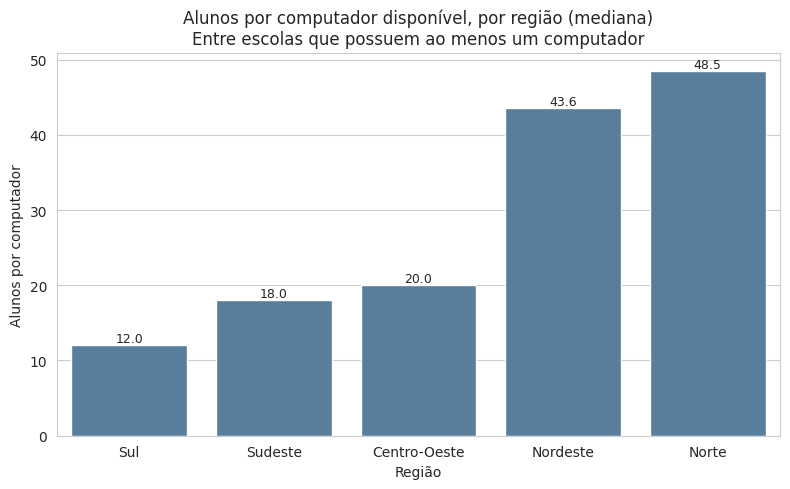

In [18]:
df_ativas["pc_total"] = df_ativas["qt_desktop_aluno"] + df_ativas["qt_comp_portatil_aluno"]
com_pc = df_ativas[df_ativas["pc_total"] > 0].copy()
com_pc["aluno_por_pc"] = com_pc["qt_mat_bas"] / com_pc["pc_total"]
mediana_aluno_pc = com_pc.groupby("no_regiao")["aluno_por_pc"].median().sort_values()
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=mediana_aluno_pc.index, y=mediana_aluno_pc.values, color=COR_PADRAO)
plt.title("Alunos por computador disponível, por região (mediana)\nEntre escolas que possuem ao menos um computador")
plt.xlabel("Região")
plt.ylabel("Alunos por computador")
rotular_barras(ax, formato="{:.1f}")
plt.tight_layout()
plt.savefig("graficos/16_alunos_por_computador_regiao.png")
plt.show()
plt.close()

## Recursos por porte da escola (achado: escola pequena tem muito menos recurso)

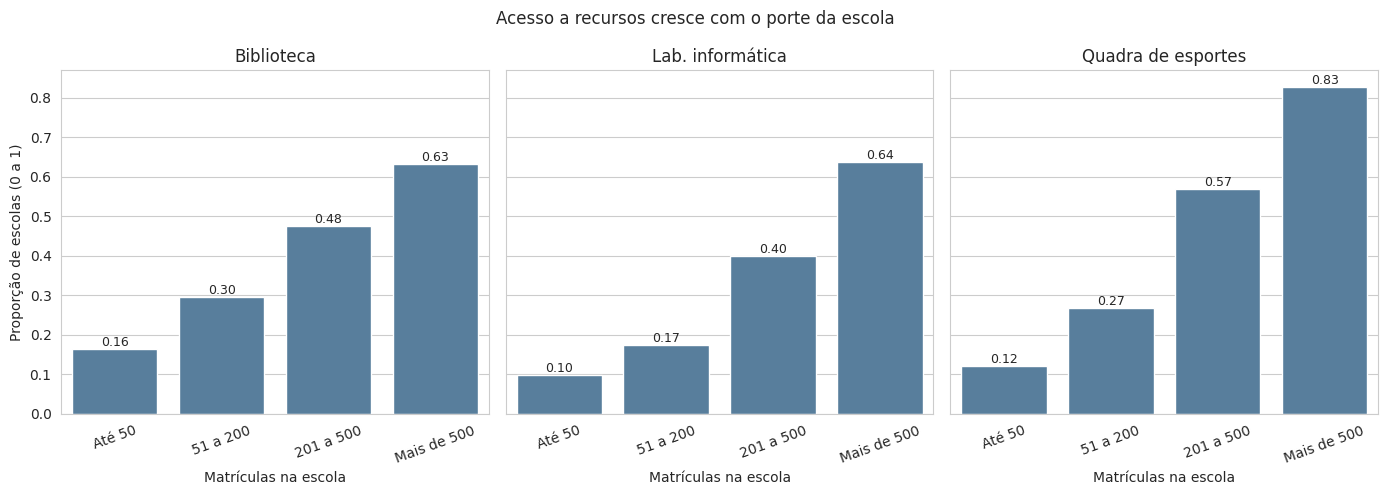

In [19]:
# Usa subplots para comparar 3 recursos lado a lado, todos em função do mesmo eixo x (porte)
bins_porte2 = [-1, 50, 200, 500, float("inf")]
labels_porte2 = ["Até 50", "51 a 200", "201 a 500", "Mais de 500"]
df_ativas["porte_mat"] = pd.cut(df_ativas["qt_mat_bas"], bins=bins_porte2, labels=labels_porte2)
recursos_porte = df_ativas.groupby("porte_mat")[
    ["in_biblioteca", "in_laboratorio_informatica", "in_quadra_esportes"]
].mean()

fig, eixos = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
recursos_plot = [
    ("in_biblioteca", "Biblioteca"),
    ("in_laboratorio_informatica", "Lab. informática"),
    ("in_quadra_esportes", "Quadra de esportes"),
]
for eixo, (coluna, nome) in zip(eixos, recursos_plot):
    sns.barplot(x=recursos_porte.index, y=recursos_porte[coluna], color=COR_PADRAO, ax=eixo)
    eixo.set_title(nome)
    eixo.set_xlabel("Matrículas na escola")
    eixo.set_ylabel("Proporção de escolas (0 a 1)")
    eixo.tick_params(axis="x", rotation=20)
    rotular_barras(eixo, formato="{:.2f}")
fig.suptitle("Acesso a recursos cresce com o porte da escola")
plt.tight_layout()
plt.savefig("graficos/17_recursos_por_porte.png")
plt.show()
plt.close()

## Água e energia: região x localização (achado: dupla desvantagem rural+Norte)

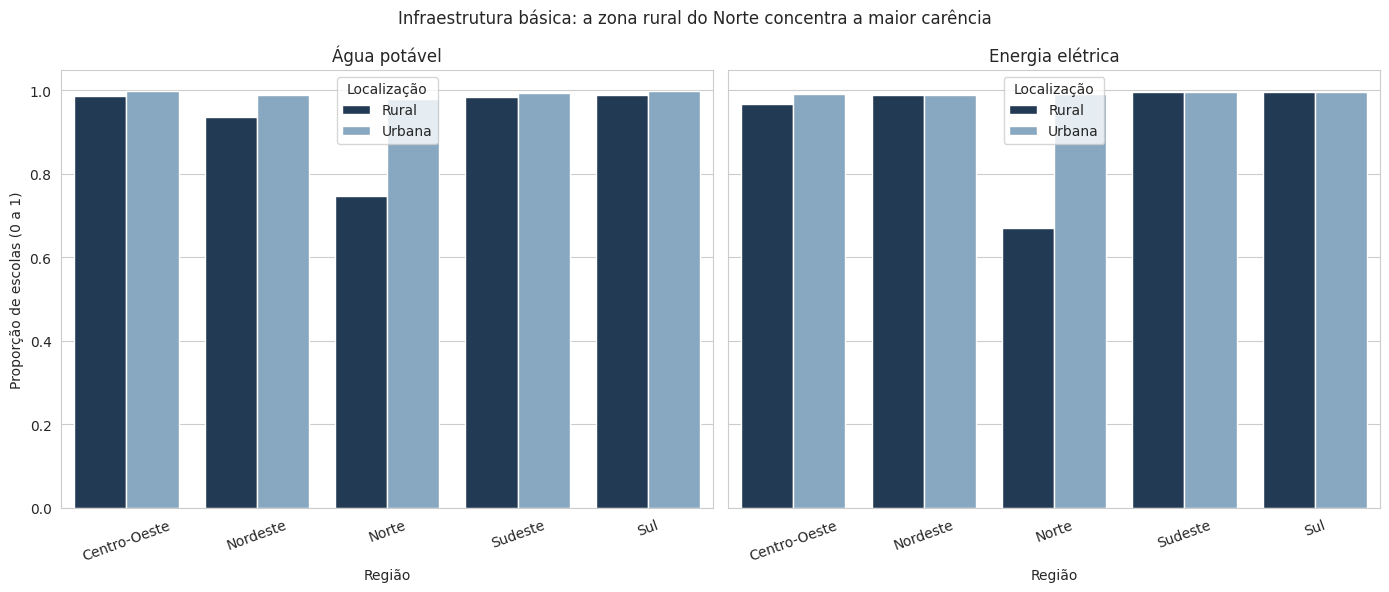

In [20]:
# Subplots comparando os dois recursos básicos, cada um com região x localização
fig, eixos = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for eixo, (coluna, nome) in zip(eixos, [("in_agua_potavel", "Água potável"),
                                         ("in_energia_rede_publica", "Energia elétrica")]):
    cruzamento = df_ativas.groupby(["no_regiao", "localizacao"])[coluna].mean().reset_index()
    sns.barplot(data=cruzamento, x="no_regiao", y=coluna, hue="localizacao",
                palette=[PALETA[1], PALETA[4]], ax=eixo)
    eixo.set_title(nome)
    eixo.set_xlabel("Região")
    eixo.set_ylabel("Proporção de escolas (0 a 1)")
    eixo.tick_params(axis="x", rotation=20)
    eixo.legend(title="Localização")
fig.suptitle("Infraestrutura básica: a zona rural do Norte concentra a maior carência")
plt.tight_layout()
plt.savefig("graficos/18_agua_energia_regiao_localizacao.png")
plt.show()
plt.close()

## Proporção de escolas com EJA por dependência administrativa (achado: quase ausente em privada)

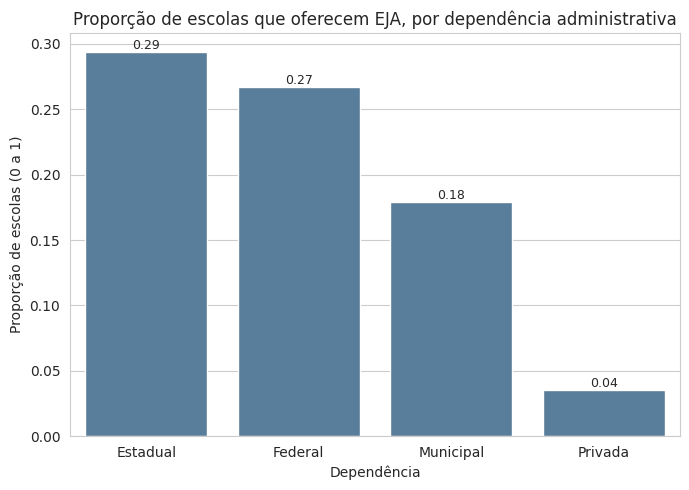

Gráficos gerados na pasta 'graficos/'.


In [21]:
df_ativas["tem_eja"] = df_ativas["qt_mat_eja"] > 0
prop_eja_dependencia = df_ativas.groupby("dependencia")["tem_eja"].mean().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
ax = sns.barplot(x=prop_eja_dependencia.index, y=prop_eja_dependencia.values, color=COR_PADRAO)
plt.title("Proporção de escolas que oferecem EJA, por dependência administrativa")
plt.xlabel("Dependência")
plt.ylabel("Proporção de escolas (0 a 1)")
rotular_barras(ax, formato="{:.2f}")
plt.tight_layout()
plt.savefig("graficos/19_eja_por_dependencia.png")
plt.show()
plt.close()

print("Gráficos gerados na pasta 'graficos/'.")